# Veri Bilimi Eğitimi


## Kategorik Veri Analizi
Amaç:
  1. Veri setindeki kategorik sütunları incelemek ve dağılımlarını analiz etmek
  2. Frekans, oran ve görselleştirme yöntemleri ile kategorik verileri yorumlama

Adımlar:
  1. Veri setini yüklemek
  2. Kategorik sütunları belirlemek
  3. Kategorik sütunların genel bilgisini incelemek
  4. Her kategorik sütun için frekans analizi yapmak
  5. Her kategorik sütun için oran analizi yapmak
  6. En sık görülen kategorileri incele
  7. En az görülen kategorileri incele
  8. Belirli sütunlar üzerinde detaylı kategorik analiz
  9. Belirli sütunlar için count plot çizdirme

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # görselleştirme
import seaborn as sns # görselleştirme

In [ ]:
# 1. veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [ ]:
# 2. kategorik sütunları belirle
kategorik_sutunlar = df.select_dtypes(include = ["object", "category"]).columns.tolist()
kategorik_sutunlar

['siparis_id',
 'musteri_id',
 'siparis_tarihi',
 'sehir',
 'bolge',
 'kategori',
 'urun_adi',
 'odeme_turu',
 'musteri_tipi',
 'iade_durumu',
 'haftanin_gunu']

In [ ]:
# 3. kategorik sutunların genel bilgisinin incelenmesi
for sutun in kategorik_sutunlar:
  print(f"sutun adı: {sutun}")
  print(f"veri tipi: {df[sutun].dtype}")
  print(f"benzersiz deger sayısı: {df[sutun].nunique()}")
  print()

sutun adı: siparis_id
veri tipi: object
benzersiz deger sayısı: 1095

sutun adı: musteri_id
veri tipi: object
benzersiz deger sayısı: 411

sutun adı: siparis_tarihi
veri tipi: object
benzersiz deger sayısı: 1094

sutun adı: sehir
veri tipi: object
benzersiz deger sayısı: 14

sutun adı: bolge
veri tipi: object
benzersiz deger sayısı: 6

sutun adı: kategori
veri tipi: object
benzersiz deger sayısı: 6

sutun adı: urun_adi
veri tipi: object
benzersiz deger sayısı: 28

sutun adı: odeme_turu
veri tipi: object
benzersiz deger sayısı: 5

sutun adı: musteri_tipi
veri tipi: object
benzersiz deger sayısı: 3

sutun adı: iade_durumu
veri tipi: object
benzersiz deger sayısı: 2

sutun adı: haftanin_gunu
veri tipi: object
benzersiz deger sayısı: 7



In [ ]:
# 4. her kategorik sütun için frekans analizi yapalım
for sutun in kategorik_sutunlar:
  print(df[sutun].value_counts())
  print()

siparis_id
SIP100642    1
SIP101125    1
SIP100263    1
SIP100707    1
SIP100687    1
            ..
SIP100161    1
SIP100320    1
SIP101066    1
SIP101295    1
SIP100308    1
Name: count, Length: 1095, dtype: int64

musteri_id
MUS1433    9
MUS1360    7
MUS1289    7
MUS1072    6
MUS1177    6
          ..
MUS1443    1
MUS1335    1
MUS1375    1
MUS1239    1
MUS1088    1
Name: count, Length: 411, dtype: int64

siparis_tarihi
2025-01-09 13:12:00    2
2025-04-30 22:18:00    1
2025-05-06 10:33:00    1
2025-04-02 08:16:00    1
2025-07-08 14:48:00    1
                      ..
2024-12-19 19:50:00    1
2024-06-20 20:17:00    1
2024-04-14 19:49:00    1
2025-04-16 10:53:00    1
2025-08-31 15:11:00    1
Name: count, Length: 1094, dtype: int64

sehir
İstanbul     264
Ankara       124
İzmir        118
Antalya       86
Konya         77
Bursa         67
Adana         63
Gaziantep     49
Mersin        46
Samsun        45
Eskişehir     45
Trabzon       44
Kayseri       36
Kocaeli       31
Name: count, d

In [ ]:
# 5. her kategorik sütun için oran analizi yapalım
for sutun in kategorik_sutunlar:
  print((df[sutun].value_counts(normalize = True) * 100).round(2))
  print()

siparis_id
SIP100642    0.09
SIP101125    0.09
SIP100263    0.09
SIP100707    0.09
SIP100687    0.09
             ... 
SIP100161    0.09
SIP100320    0.09
SIP101066    0.09
SIP101295    0.09
SIP100308    0.09
Name: proportion, Length: 1095, dtype: float64

musteri_id
MUS1433    0.82
MUS1360    0.64
MUS1289    0.64
MUS1072    0.55
MUS1177    0.55
           ... 
MUS1443    0.09
MUS1335    0.09
MUS1375    0.09
MUS1239    0.09
MUS1088    0.09
Name: proportion, Length: 411, dtype: float64

siparis_tarihi
2025-01-09 13:12:00    0.18
2025-04-30 22:18:00    0.09
2025-05-06 10:33:00    0.09
2025-04-02 08:16:00    0.09
2025-07-08 14:48:00    0.09
                       ... 
2024-12-19 19:50:00    0.09
2024-06-20 20:17:00    0.09
2024-04-14 19:49:00    0.09
2025-04-16 10:53:00    0.09
2025-08-31 15:11:00    0.09
Name: proportion, Length: 1094, dtype: float64

sehir
İstanbul     24.11
Ankara       11.32
İzmir        10.78
Antalya       7.85
Konya         7.03
Bursa         6.12
Adana         5.75

In [ ]:
# 6. en sık görülen kategorileri incele
for sutun in kategorik_sutunlar:
  print()
  print(df[sutun].value_counts().head(3))


siparis_id
SIP100642    1
SIP101125    1
SIP100263    1
Name: count, dtype: int64

musteri_id
MUS1433    9
MUS1360    7
MUS1289    7
Name: count, dtype: int64

siparis_tarihi
2025-01-09 13:12:00    2
2025-04-30 22:18:00    1
2025-05-06 10:33:00    1
Name: count, dtype: int64

sehir
İstanbul    264
Ankara      124
İzmir       118
Name: count, dtype: int64

bolge
Marmara       350
İç Anadolu    284
Akdeniz       195
Name: count, dtype: int64

kategori
Kitap       223
Kozmetik    200
Spor        186
Name: count, dtype: int64

urun_adi
Suluk             51
Powerbank         49
Zaman Yönetimi    47
Name: count, dtype: int64

odeme_turu
Kredi Kartı       583
Banka Kartı       169
Dijital Cüzdan    153
Name: count, dtype: int64

musteri_tipi
Mevcut    558
Yeni      409
VIP       128
Name: count, dtype: int64

iade_durumu
Hayır    1007
Evet       88
Name: count, dtype: int64

haftanin_gunu
Saturday     169
Tuesday      169
Wednesday    163
Name: count, dtype: int64


In [ ]:
# 7. en az görülen kategorileri incele
for sutun in kategorik_sutunlar:
  print()
  print(df[sutun].value_counts().tail(3))


siparis_id
SIP101066    1
SIP101295    1
SIP100308    1
Name: count, dtype: int64

musteri_id
MUS1375    1
MUS1239    1
MUS1088    1
Name: count, dtype: int64

siparis_tarihi
2024-04-14 19:49:00    1
2025-04-16 10:53:00    1
2025-08-31 15:11:00    1
Name: count, dtype: int64

sehir
Trabzon    44
Kayseri    36
Kocaeli    31
Name: count, dtype: int64

bolge
Ege                  124
Karadeniz             92
Güneydoğu Anadolu     50
Name: count, dtype: int64

kategori
Ev Yaşam      184
Ofis          162
Elektronik    140
Name: count, dtype: int64

urun_adi
Bluetooth Hoparlör    32
Kablosuz Kulaklık     25
Dambıl Seti           25
Name: count, dtype: int64

odeme_turu
Dijital Cüzdan    153
Havale/EFT        111
Kapıda Ödeme       79
Name: count, dtype: int64

musteri_tipi
Mevcut    558
Yeni      409
VIP       128
Name: count, dtype: int64

iade_durumu
Hayır    1007
Evet       88
Name: count, dtype: int64

haftanin_gunu
Sunday    150
Monday    144
Friday    143
Name: count, dtype: int64


In [ ]:
# 8. belirli sütunlar üzerinde detaylı kategorik analiz
detayli_analiz_sutunlari = ["sehir", "kategori", "odeme_turu", "musteri_tipi"]

for sutun in detayli_analiz_sutunlari:
  if sutun in df.columns:
    print("Frekanslar:")
    print(df[sutun].value_counts())

    print("Oranlar:")
    print((df[sutun].value_counts(normalize = True) * 100).round(2))
    print()

Frekanslar:
sehir
İstanbul     264
Ankara       124
İzmir        118
Antalya       86
Konya         77
Bursa         67
Adana         63
Gaziantep     49
Mersin        46
Samsun        45
Eskişehir     45
Trabzon       44
Kayseri       36
Kocaeli       31
Name: count, dtype: int64
Oranlar:
sehir
İstanbul     24.11
Ankara       11.32
İzmir        10.78
Antalya       7.85
Konya         7.03
Bursa         6.12
Adana         5.75
Gaziantep     4.47
Mersin        4.20
Samsun        4.11
Eskişehir     4.11
Trabzon       4.02
Kayseri       3.29
Kocaeli       2.83
Name: proportion, dtype: float64

Frekanslar:
kategori
Kitap         223
Kozmetik      200
Spor          186
Ev Yaşam      184
Ofis          162
Elektronik    140
Name: count, dtype: int64
Oranlar:
kategori
Kitap         20.37
Kozmetik      18.26
Spor          16.99
Ev Yaşam      16.80
Ofis          14.79
Elektronik    12.79
Name: proportion, dtype: float64

Frekanslar:
odeme_turu
Kredi Kartı       583
Banka Kartı       169
Dijital C

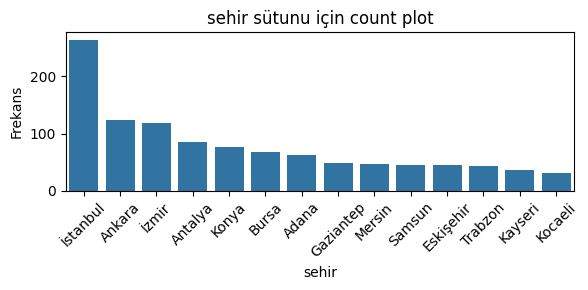

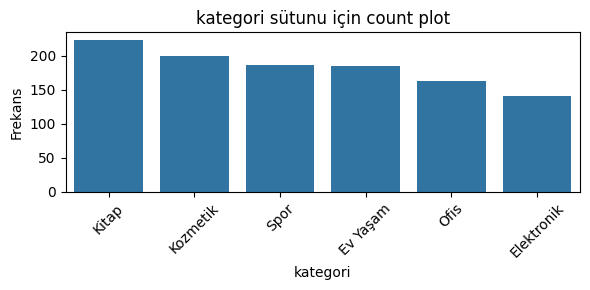

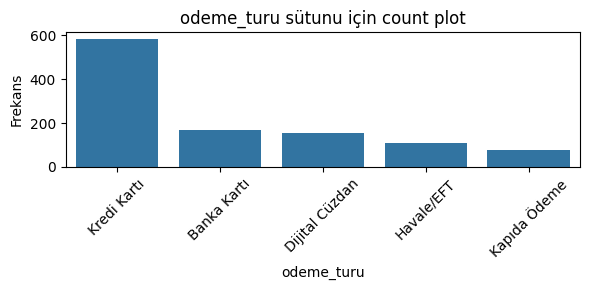

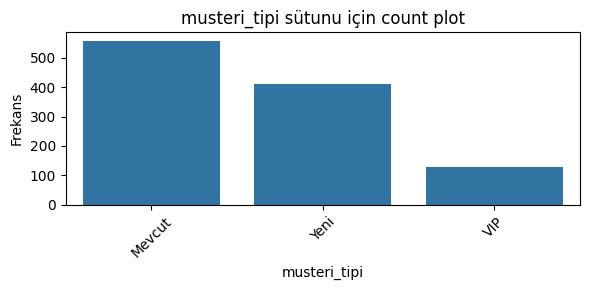

In [ ]:
# 9. belirli sütunlar için count plot çizdirme
for sutun in detayli_analiz_sutunlari:
  if sutun in df.columns:
    plt.figure(figsize = (6,3))
    sns.countplot(data = df, x = sutun, order = df[sutun].value_counts().index)
    plt.title(f"{sutun} sütunu için count plot")
    plt.xlabel(sutun)
    plt.ylabel("Frekans")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

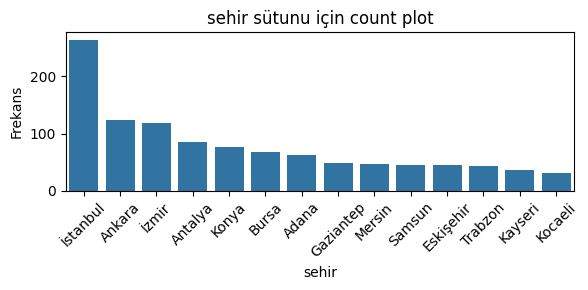

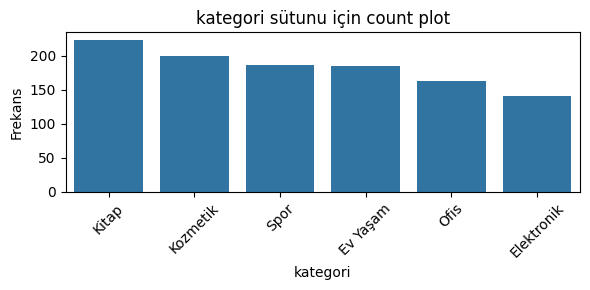

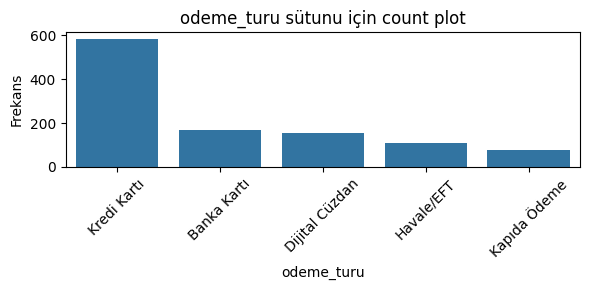

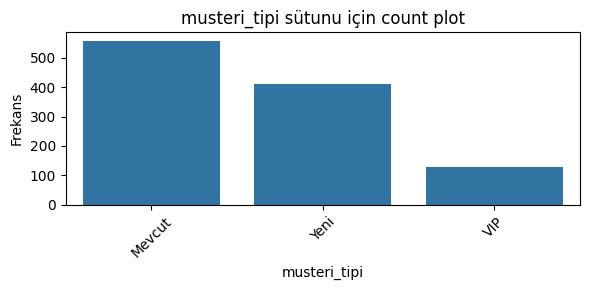

In [ ]:
# 10. belirli sütunların oranları için count plot çizdirme
for sutun in detayli_analiz_sutunlari:
  if sutun in df.columns:
    plt.figure(figsize = (6,3))
    sns.countplot(data = df, x = sutun, order = ((df[sutun].value_counts(normalize=True)*100).round(2)).index)
    plt.title(f"{sutun} sütunu için count plot")
    plt.xlabel(sutun)
    plt.ylabel("Frekans")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()